# Тема 1. Моделирование геометрической вероятности.
Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.

> Задача: Пол выложен одинаковыми квадратными плитками, сторона каждой из которых равна L. На пол наудачу бросается круглая монета радиуса r (при этом 2r < L, то есть диаметр монеты меньше стороны плитки).Найдите вероятность того, что упавшая монета полностью окажется внутри одной из плиток, то есть не пересечет ни одну из линий, разделяющих плитки.

In [56]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

L = 10
r = 2

num_drops = 1000
full_shown = 3

theor_probability = (L - 2*r)**2 / L**2
print(f"Теоретическая вероятность бесшовного падения: {theor_probability}")

Теоретическая вероятность бесшовного падения: 0.36


In [57]:
x_centers = np.random.uniform(0, L, num_drops)
y_centers = np.random.uniform(0, L, num_drops)

inside_safe_zone = (x_centers >= r) & (x_centers <= L - r) & (y_centers >= r) & (y_centers <= L - r)

exp_probability = np.sum(inside_safe_zone) / num_drops
print(f"На плитку из {num_drops} монеток бесшовно упало {np.sum(inside_safe_zone)}. Доля упавших бесшовно равна {exp_probability}")

На плитку из 1000 монеток бесшовно упало 342. Доля упавших бесшовно равна 0.342


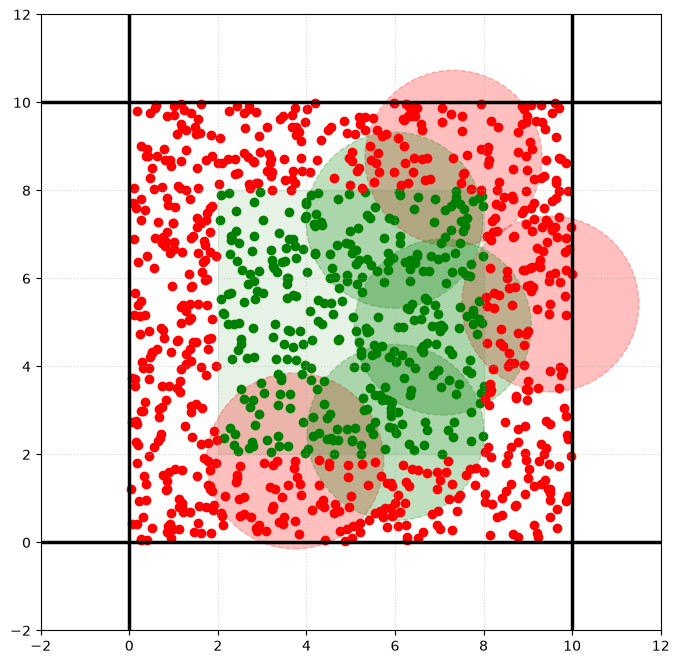

In [58]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.axhline(0, color='black', linewidth=2.5)
ax.axhline(L, color='black', linewidth=2.5)
ax.axvline(0, color='black', linewidth=2.5)
ax.axvline(L, color='black', linewidth=2.5)

ax.fill_between([r, L-r], r, L-r, color='green', alpha=0.1)

shown_success, shown_fail = 0, 0
for x, y, is_inside in zip(x_centers, y_centers, inside_safe_zone):
    if is_inside and shown_success < full_shown:
        coin = plt.Circle((x, y), r, color='green', fill=True, alpha=0.25, linestyle='--')
        ax.add_patch(coin)
        shown_success += 1
    elif not is_inside and shown_fail < full_shown:
        coin = plt.Circle((x, y), r, color='red', fill=True, alpha=0.25, linestyle='--')
        ax.add_patch(coin)
        shown_fail += 1


ax.scatter(x_centers[inside_safe_zone], y_centers[inside_safe_zone], color='green')
ax.scatter(x_centers[~inside_safe_zone], y_centers[~inside_safe_zone], color='red')

ax.set_xlim(-r, L + r)
ax.set_ylim(-r, L + r)
ax.grid(True, linestyle=':', alpha=0.5)


plt.show()